# PraesagiumChain — Simulation and Efficiency Test

This notebook tests the CRE (Chainlink Request & Execution) flow and measures project efficiency:
- **API sentiment** (`/api/ai/sentiment`) — Sentiment analysis with Gemini
- **API predict** (`/api/predict`, `/api/predict/hybrid`) — PHPE and hybrid predictions
- Metrics: latency, throughput, consistency

## 1. Configuración y dependencias

In [81]:
import requests
import time
import json
from typing import Optional

API_BASE = "http://localhost:4000"  # Change if backend runs on another port

def check_backend() -> bool:
    try:
        r = requests.get(f"{API_BASE}/health", timeout=2)
        return r.status_code == 200
    except Exception:
        return False

if check_backend():
    print(f"✓ Backend available at {API_BASE}")
else:
    print(f"⚠ Backend not available at {API_BASE}. Run: npm run backend")
    print("  (Latency tests will fail, but the notebook can be used to understand the flow)")

✓ Backend available at http://localhost:4000


## 2. Sentiment API test (simulated CRE flow)

In [82]:
def call_sentiment(text: str) -> tuple[dict, float]:
    """Calls the sentiment endpoint and returns (response, latency_ms)."""
    url = f"{API_BASE}/api/ai/sentiment"
    body = {"text": text}
    start = time.perf_counter()
    r = requests.post(url, json=body, timeout=30)
    elapsed_ms = (time.perf_counter() - start) * 1000
    if r.status_code != 200:
        err = r.json() if 'application/json' in r.headers.get('content-type','') else {}
        raise RuntimeError(f"API {r.status_code}: {err.get('error', r.text)}")
    return r.json(), elapsed_ms


texto = "Bitcoin will reach 100k this year"
try:
    data, latency = call_sentiment(texto)
    prob = data.get("probability", 0.5)
    outcome = 1 if prob >= 0.5 else 0
    print(f"Text: {texto}")
    print(f"Response: {json.dumps(data, indent=2)}")
    print(f"Simulated outcome: {outcome} ({'Yes' if outcome else 'No'})")
    print(f"Latency: {latency:.1f} ms")
except Exception as e:
    print(f"Error: {e}")

Text: Bitcoin will reach 100k this year
Response: {
  "provider": "mock",
  "sentiment_score": 0.0,
  "probability": 0.5
}
Simulated outcome: 1 (Yes)
Latency: 7.5 ms


## 3. Hybrid Predict API test

In [83]:
def call_hybrid(sentiment_text: Optional[str] = None, binance_symbol: Optional[str] = None,
                use_chainlink: bool = False) -> tuple[dict, float]:
    url = f"{API_BASE}/api/predict/hybrid"
    body = {}
    if sentiment_text:
        body["sentiment_text"] = sentiment_text
    if binance_symbol:
        body["binance_symbol"] = binance_symbol
    if use_chainlink:
        body["use_chainlink_price"] = True
    start = time.perf_counter()
    r = requests.post(url, json=body, timeout=30)
    elapsed_ms = (time.perf_counter() - start) * 1000
    r.raise_for_status()
    return r.json(), elapsed_ms


try:
    data, latency = call_hybrid(
        sentiment_text="Bitcoin going up",
        binance_symbol="BTCUSDT"
    )
    print(f"Hybrid response: {json.dumps(data, indent=2)}")
    print(f"Latency: {latency:.1f} ms")
except Exception as e:
    print(f"Error: {e}")

Hybrid response: {
  "probability": 0.56068486,
  "uncertainty": null,
  "market_id": null
}
Latency: 289.7 ms


## 4. Efficiency benchmarks

In [84]:
def benchmark_sentiment(n: int = 5, text: str = "Bitcoin bullish") -> list[float]:
    latencies = []
    errors = 0
    for _ in range(n):
        try:
            _, latency = call_sentiment(text)
            latencies.append(latency)
        except Exception:
            errors += 1
    if errors:
        print(f"Warning: {errors} calls failed")
    return latencies


N = 5
latencies = benchmark_sentiment(N)

if latencies:
    avg = sum(latencies) / len(latencies)
    mín = min(latencies)
    máx = max(latencies)
    print(f"\n--- Benchmark Sentiment ({N} calls) ---")
    print(f"Average latency: {avg:.1f} ms")
    print(f"Min latency:   {mín:.1f} ms")
    print(f"Max latency:   {máx:.1f} ms")
    print(f"Approx throughput: {1000/avg:.2f} req/s (sequential)")


--- Benchmark Sentiment (5 calls) ---
Average latency: 8.3 ms
Min latency:   5.5 ms
Max latency:   10.6 ms
Approx throughput: 120.53 req/s (sequential)


## 5. Latency visualization (optional)

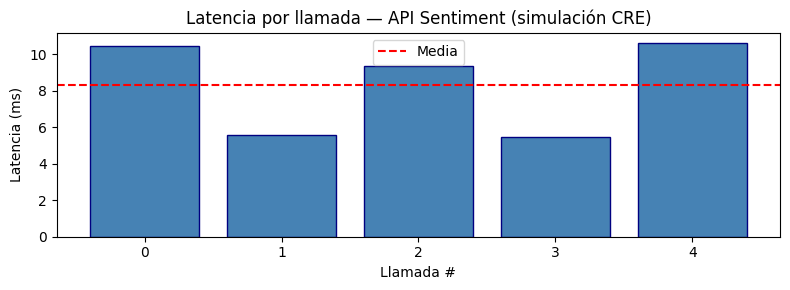

In [85]:
try:
    import matplotlib.pyplot as plt

    if latencies:
        fig, ax = plt.subplots(figsize=(8, 3))
        ax.bar(range(len(latencies)), latencies, color="steelblue", edgecolor="navy")
        ax.axhline(y=sum(latencies)/len(latencies), color="red", linestyle="--", label="Mean")
        ax.set_xlabel("Call #")
        ax.set_ylabel("Latency (ms)")
        ax.set_title("Latency per call — Sentiment API (CRE simulation)")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No latency data to plot.")
except ImportError:
    print("To plot: pip install matplotlib")

## 5.1 Real-time chart (live monitoring)

Run the cell below to see latency update in real time. It will restart each time you run it. Stop with the ■ (Stop) button when you want to quit.

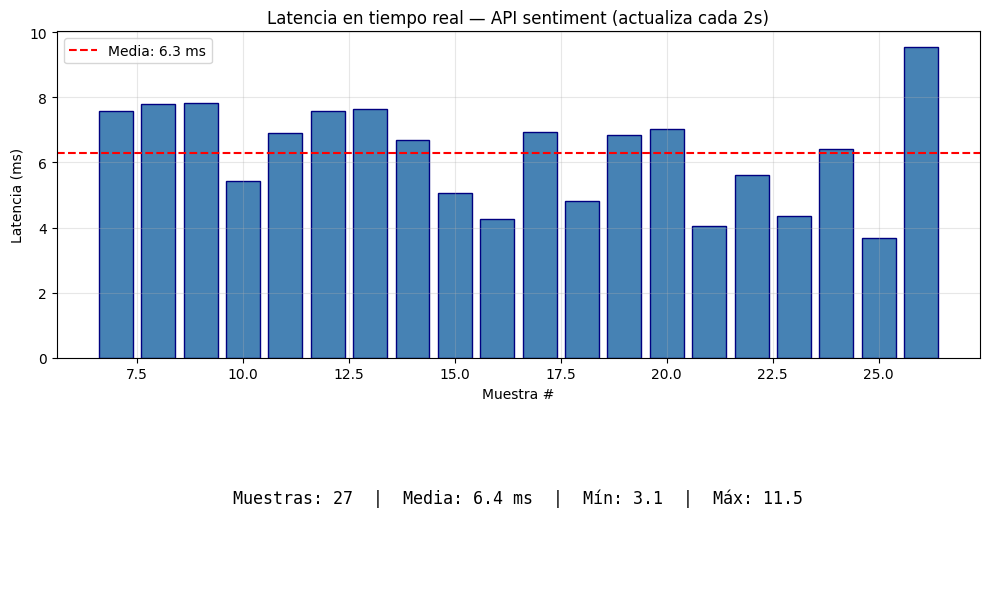

✓ Monitoreo completado.


In [86]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import numpy as np

# Configuración
DURACION_SEG = 60   # Cuántos segundos monitorear (interrumpe antes si quieres)
INTERVALO_SEG = 2  # Llamada al API cada N segundos
endpoint = "sentiment"  # "sentiment" o "hybrid"

def medir_latencia():
    if endpoint == "sentiment":
        _, lat = call_sentiment("Bitcoin bullish")
    else:
        _, lat = call_hybrid(sentiment_text="BTC up", binance_symbol="BTCUSDT")
    return lat

latencies_realtime = []
inicio = time.perf_counter()

try:
    while (time.perf_counter() - inicio) < DURACION_SEG:
        try:
            lat = medir_latencia()
            latencies_realtime.append(lat)
        except Exception as e:
            latencies_realtime.append(0)  # failure = 0 to avoid breaking the chart
        
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={"height_ratios": [2, 1]})
        
        # Bar chart (last 20 samples)
        n = len(latencies_realtime)
        xs = list(range(max(0, n - 20), n))
        ys = latencies_realtime[-20:]
        ax1.bar(xs, ys, color="steelblue", edgecolor="navy")
        if ys:
            ax1.axhline(y=np.mean(ys), color="red", linestyle="--", label=f"Mean: {np.mean(ys):.1f} ms")
        ax1.set_xlabel("Sample #")
        ax1.set_ylabel("Latency (ms)")
        ax1.set_title(f"Real-time latency — API {endpoint} (updates every {INTERVALO_SEG}s)")
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Statistics
        if latencies_realtime:
            ax2.axis("off")
            avg = np.mean(latencies_realtime)
            ax2.text(0.5, 0.5, f"Samples: {len(latencies_realtime)}  |  Mean: {avg:.1f} ms  |  Min: {min(latencies_realtime):.1f}  |  Max: {max(latencies_realtime):.1f}", 
                     ha="center", va="center", fontsize=12, family="monospace")
        plt.tight_layout()
        plt.show()
        
        time.sleep(INTERVALO_SEG)
    print("✓ Monitoring complete.")
except KeyboardInterrupt:
    print("Stopped by user.")

## 6. Efficiency summary

| Metric | Interpretation |
|--------|----------------|
| **Average latency** | Time it takes for backend + AI to respond. CRE simulates this off-chain. |
| **Throughput** | Practical limit of markets that can be resolved per second (sequential). |
| **Consistency** | If min/max differ a lot, the API may be unstable. |

In production, Chainlink CRE runs this flow off-chain and uploads the outcome on-chain securely.